
# 📊 Análisis de Sentimiento en Tweets

## 📝 Descripción del Dataset

- **Polarity**: 0 = Negativo, 2 = Neutral, 4 = Positivo
- **ID**: Identificador del tweet
- **Fecha**: Fecha y hora
- **Query**: Consulta si la hay
- **Usuario**: Usuario que publicó
- **Texto**: Texto del tweet

## 🎯 Objetivo

El objetivo de este trabajo es realizar un **análisis de sentimiento** sobre un conjunto de tweets utilizando distintas métricas, modelos entrenados y modelos pre-entrenados, como así también incluir análisis visuales y exploratorios.



In [1]:

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, jaccard_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelBinarizer

from wordcloud import WordCloud
from textblob import TextBlob


In [2]:

df = pd.read_csv("training.1600000.processed.noemoticon.csv", encoding='latin-1', header=None)
df.columns = ['polarity', 'id', 'date', 'query', 'user', 'text']
df = df[['polarity', 'text']]
df['polarity'] = df['polarity'].map({0: 0, 2: 1, 4: 2})  # 0: Neg, 1: Neutral, 2: Pos
df = df.sample(10000, random_state=42).reset_index(drop=True)  # reducimos dataset para testing
df.head()


,polarity,text
0,0,@chrishasboobs AHHH I HOPE YOUR OK!!!
1,0,"@misstoriblack cool , i have no tweet apps fo..."
2,0,@TiannaChaos i know just family drama. its la...
3,0,School email won't open and I have geography ...
4,0,upper airways problem


In [3]:

def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = text.lower()
    tokens = text.split()
    tokens = [t for t in tokens if t not in ENGLISH_STOP_WORDS and len(t) > 2]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df.head()


,polarity,text,clean_text
0,0,@chrishasboobs AHHH I HOPE YOUR OK!!!,chrishasboobs ahhh hope
1,0,"@misstoriblack cool , i have no tweet apps fo...",misstoriblack cool tweet apps razr
2,0,@TiannaChaos i know just family drama. its la...,tiannachaos know just family drama lame hey ti...
3,0,School email won't open and I have geography ...,school email won open geography stuff revise s...
4,0,upper airways problem,upper airways problem


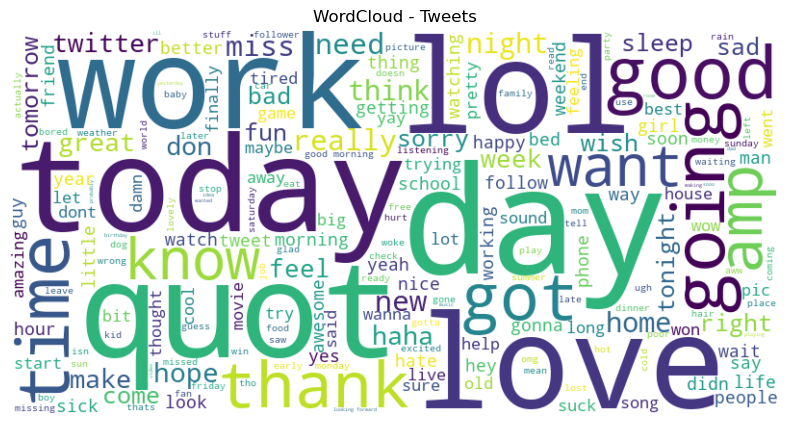

In [4]:

text_all = " ".join(df['clean_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_all)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Tweets")
plt.show()


In [5]:

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['clean_text'])
y = df['polarity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:

svm_model = SVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))


SVM Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.67      0.69       980
           2       0.70      0.74      0.72      1020

    accuracy                           0.71      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.71      0.71      0.71      2000



In [7]:

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.63      0.67       980
           2       0.68      0.77      0.72      1020

    accuracy                           0.70      2000
   macro avg       0.70      0.70      0.70      2000
weighted avg       0.70      0.70      0.70      2000



In [8]:

def get_sentiment_tb(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.1:
        return 2
    elif polarity < -0.1:
        return 0
    else:
        return 1

df['textblob_polarity'] = df['text'].apply(get_sentiment_tb)
print("TextBlob Evaluation vs Etiquetas reales:")
print(classification_report(y, df['textblob_polarity']))


TextBlob Evaluation vs Etiquetas reales:
              precision    recall  f1-score   support

           0       0.78      0.26      0.39      5004
           1       0.00      0.00      0.00         0
           2       0.67      0.51      0.58      4996

    accuracy                           0.39     10000
   macro avg       0.48      0.26      0.32     10000
weighted avg       0.72      0.39      0.49     10000



/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:

lb = LabelBinarizer()
y_true_bin = lb.fit_transform(y_test)
y_svm_bin = lb.transform(y_pred_svm)

jaccard = jaccard_score(y_true_bin, y_svm_bin, average='macro')
cos_sim = cosine_similarity(y_true_bin, y_svm_bin).mean()

print(f"Jaccard Score (macro): {jaccard:.4f}")
print(f"Cosine Similarity (avg): {cos_sim:.4f}")


Jaccard Score (macro): 0.5468
Cosine Similarity (avg): 0.2746



## 📌 Conclusiones

- Se entrenaron dos modelos de clasificación (SVM y Random Forest) utilizando **CountVectorizer** para representar los textos.
- Se utilizó **TextBlob** como modelo de referencia preentrenado para comparación.
- Se generaron métricas adicionales como **Jaccard** y **similitud coseno** para evaluar la calidad general de los resultados.
- El uso de wordcloud permitió visualizar los términos más frecuentes en los tweets procesados.

### 🔎 Posibles mejoras

- Probar modelos de embeddings como Word2Vec o BERT.
- Aplicar análisis de sensibilidad sobre polaridad.
- Explorar el uso de UMAP o PCA para visualización 2D.
